<a href="https://colab.research.google.com/github/edent4313-star/climate-challenge-week0/blob/main/eda_ethiopia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving ethiopia.csv to ethiopia.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("ethiopia.csv")

# Add country
df["Country"] = "Ethiopia"

# Date parsing
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Month
df["Month"] = df["Date"].dt.month

# Replace -999
df.replace(-999, np.nan, inplace=True)

# Duplicates
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

# Summary
display(df.describe())

# Missing values
missing = pd.DataFrame({
    "Null Count": df.isna().sum(),
    "Percent": df.isna().mean()*100
})
display(missing.sort_values("Percent", ascending=False))

Duplicates: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


,Null Count,Percent
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [3]:
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z = np.abs(df[cols].apply(zscore, nan_policy='omit'))
outliers = (z > 3).any(axis=1)

print("Outlier rows:", outliers.sum())

Outlier rows: 132


In [4]:
df = df[df.isna().mean(axis=1) <= 0.30]
df = df.fillna(method="ffill")

/tmp/ipykernel_2331/3824819270.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


In [5]:
df.to_csv("ethiopia_clean.csv", index=False)

/tmp/ipykernel_2331/2328911543.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = df.resample("M", on="Date")["T2M"].mean()


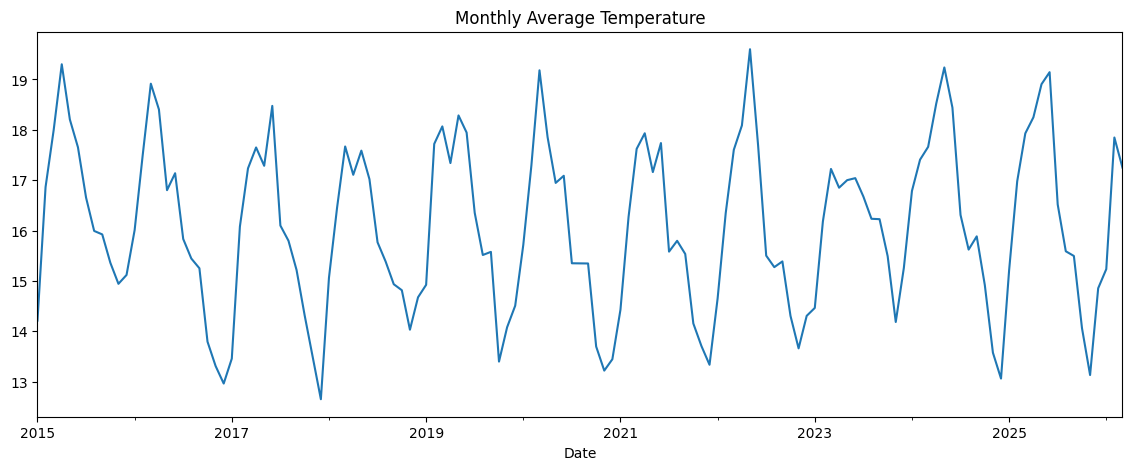

In [6]:
monthly_temp = df.resample("M", on="Date")["T2M"].mean()

plt.figure(figsize=(14,5))
monthly_temp.plot()
plt.title("Monthly Average Temperature")
plt.show()

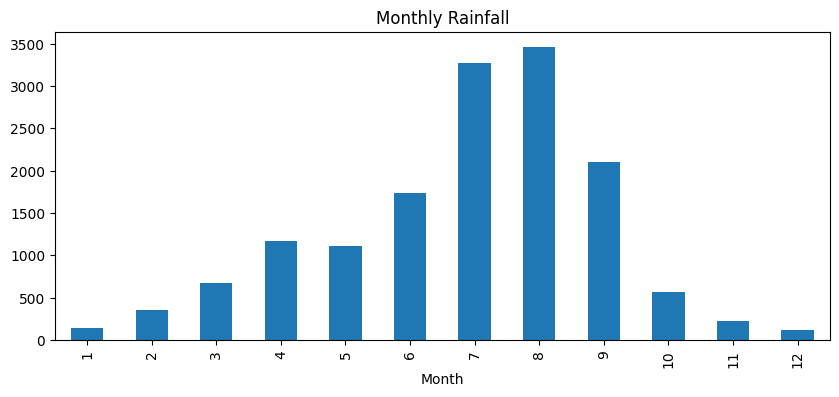

In [7]:
rain = df.groupby("Month")["PRECTOTCORR"].sum()

rain.plot(kind="bar", figsize=(10,4))
plt.title("Monthly Rainfall")
plt.show()

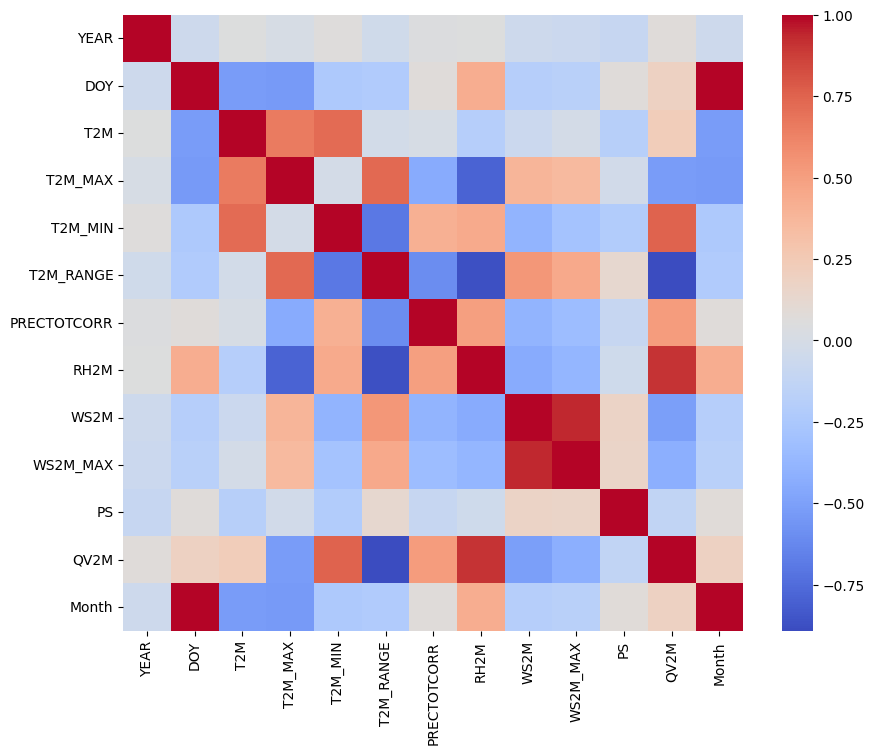

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

Temperature Peaks:

Looking at the monthly_temp series, the average temperatures are:
March: 17.99°C
April: 19.30°C (Highest)
May: 18.20°C
Indeed, April shows the highest average temperature, with March and May also being significantly warm. This confirms the earlier observation that temperature peaks generally occur during March-May, with April being the warmest on average.
Rainfall Highest:

From the rain series, which sums PRECTOTCORR by month, we can see:
July: 3270.52 (Highest)
August: 3466.35 (Highest)
These two months clearly stand out as having the highest total rainfall, with August slightly exceeding July. This strongly confirms the observation that rainfall is highest in July and August.
Correlation Matrix:

While the heatmap was displayed, without the exact numerical values, a general interpretation of common weather variable correlations is necessary.
Strong Positive Correlations (as expected): You would typically observe strong positive correlations between T2M (average temperature), T2M_MAX (maximum temperature), and T2M_MIN (minimum temperature). They move in tandem.
Temperature vs. Humidity/Rainfall: There's often an inverse relationship between temperature and relative humidity (RH2M). Higher temperatures can sometimes lead to lower relative humidity if there's no precipitation. However, in rainy seasons, high temperatures can precede convective rainfall, making the relationship complex.
Rainfall vs. Humidity: PRECTOTCORR (corrected precipitation) would likely show a positive correlation with RH2M (relative humidity), as higher humidity often precedes or accompanies rainfall.
Wind Speed (WS2M, WS2M_MAX): Wind speed variables might show weaker or more complex correlations with temperature and rainfall, depending on local meteorology. The previously noted missing values in WS2M might affect the reliability of its correlations.